# External Sampling MCCFR on Kuhn Poker

This notebook compares full-tree vanilla CFR with external-sampling MCCFR on Kuhn Poker. The code is intentionally small and explicit, following the style of the earlier vanilla CFR project.

In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
ROOT = cwd if (cwd / "src").exists() else cwd.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from cfr import VanillaCFR
from external_sampling_mccfr import ExternalSamplingMCCFR
from kuhn_poker import KuhnPoker
from util import expected_value, exploitability, format_strategy

FIG_DIR = ROOT / "report" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

efg = KuhnPoker.efg()
KUHN_VALUE = -1.0 / 18.0

## Training Helpers

In [2]:
def run_cfr(checkpoints):
    trainer = VanillaCFR(efg)
    rows = []
    previous = 0
    start = time.perf_counter()

    for step in checkpoints:
        trainer.train(int(step - previous))
        previous = int(step)
        strategy = trainer.average_strategy()
        rows.append(
            {
                "algorithm": "CFR",
                "seed": 0,
                "iterations": trainer.iterations,
                "node_visits": trainer.node_visits,
                "seconds": time.perf_counter() - start,
                "value": expected_value(efg, strategy),
                "exploitability": exploitability(efg, strategy),
            }
        )

    return trainer, pd.DataFrame(rows)


def run_external_sampling(checkpoints, seeds):
    rows = []
    trainers = []

    for seed in seeds:
        trainer = ExternalSamplingMCCFR(efg, seed=seed)
        trainers.append(trainer)
        previous = 0
        start = time.perf_counter()

        for step in checkpoints:
            trainer.train(int(step - previous))
            previous = int(step)
            strategy = trainer.average_strategy()
            rows.append(
                {
                    "algorithm": "External Sampling MCCFR",
                    "seed": seed,
                    "iterations": trainer.iterations,
                    "node_visits": trainer.node_visits,
                    "seconds": time.perf_counter() - start,
                    "value": expected_value(efg, strategy),
                    "exploitability": exploitability(efg, strategy),
                }
            )

    return trainers, pd.DataFrame(rows)


def summarize(df):
    return (
        df.groupby(["algorithm", "iterations"], as_index=False)
        .agg(
            exploitability=("exploitability", "mean"),
            exploitability_std=("exploitability", "std"),
            value=("value", "mean"),
            node_visits=("node_visits", "mean"),
            seconds=("seconds", "mean"),
        )
        .fillna(0.0)
    )

## Run Experiments

In [3]:
cfr_checkpoints = np.unique(np.logspace(1, 4, 22, dtype=int))
mccfr_checkpoints = np.unique(np.logspace(1, 5, 28, dtype=int))
seeds = [0, 1, 2]

cfr_trainer, cfr_df = run_cfr(cfr_checkpoints)
mccfr_trainers, mccfr_df = run_external_sampling(mccfr_checkpoints, seeds)

results = pd.concat([cfr_df, mccfr_df], ignore_index=True)
summary = summarize(results)
summary.tail()

,algorithm,iterations,exploitability,exploitability_std,value,node_visits,seconds
45,External Sampling MCCFR,25550,0.004634,0.002618,-0.055564,3.230417e+05,1.242045
46,External Sampling MCCFR,35938,0.003244,0.001915,-0.055631,4.536980e+05,1.715472
47,External Sampling MCCFR,50547,0.003133,0.001427,-0.055572,6.370107e+05,2.402558
48,External Sampling MCCFR,71097,0.002166,0.001116,-0.055579,8.943663e+05,3.363567
49,External Sampling MCCFR,100000,0.001746,0.001159,-0.055551,1.258342e+06,4.713543


In [4]:
final = summary.sort_values(["algorithm", "iterations"]).groupby("algorithm").tail(1)
final[["algorithm", "iterations", "value", "exploitability", "node_visits", "seconds"]]

,algorithm,iterations,value,exploitability,node_visits,seconds
21,CFR,10000,-0.055561,0.001982,1.100000e+06,2.001727
49,External Sampling MCCFR,100000,-0.055551,0.001746,1.258342e+06,4.713543


In [5]:
print("Known Kuhn value:", f"{KUHN_VALUE:.8f}")
print("\nCFR average strategy")
print(format_strategy(cfr_trainer.average_strategy()))

best_mccfr = mccfr_trainers[0]
print("\nExternal Sampling MCCFR average strategy, seed 0")
print(format_strategy(best_mccfr.average_strategy()))

Known Kuhn value: -0.05555556

CFR average strategy
{'J': {'check': 0.7727, 'bet': 0.2273}, 'J|bet': {'call': 0.0, 'fold': 1.0}, 'J|check': {'check': 0.6697, 'bet': 0.3303}, 'J|check-bet': {'call': 0.0, 'fold': 1.0}, 'K': {'check': 0.2978, 'bet': 0.7022}, 'K|bet': {'call': 1.0, 'fold': 0.0}, 'K|check': {'check': 0.0002, 'bet': 0.9998}, 'K|check-bet': {'call': 1.0, 'fold': 0.0}, 'Q': {'check': 0.9994, 'bet': 0.0006}, 'Q|bet': {'call': 0.3321, 'fold': 0.6679}, 'Q|check': {'check': 0.9998, 'bet': 0.0002}, 'Q|check-bet': {'call': 0.5632, 'fold': 0.4368}}

External Sampling MCCFR average strategy, seed 0
{'J': {'check': 0.7311, 'bet': 0.2689}, 'J|bet': {'call': 0.0, 'fold': 1.0}, 'J|check': {'check': 0.6675, 'bet': 0.3325}, 'J|check-bet': {'call': 0.0, 'fold': 1.0}, 'K': {'check': 0.2056, 'bet': 0.7944}, 'K|bet': {'call': 1.0, 'fold': 0.0}, 'K|check': {'check': 0.0003, 'bet': 0.9997}, 'K|check-bet': {'call': 1.0, 'fold': 0.0}, 'Q': {'check': 0.999, 'bet': 0.001}, 'Q|bet': {'call': 0.3364, '

## Plots

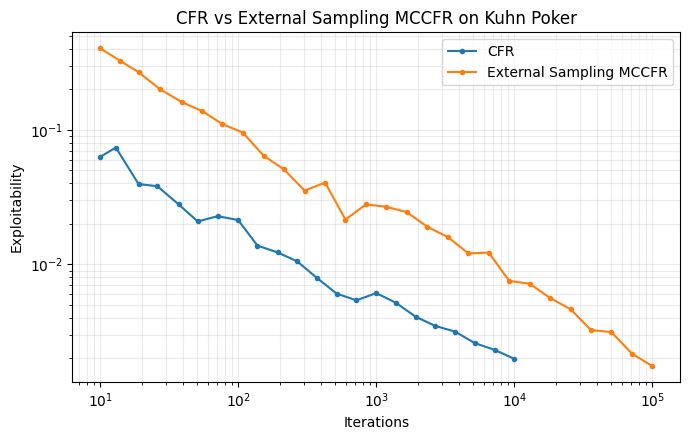

In [6]:
fig, ax = plt.subplots(figsize=(7.0, 4.5))

for algorithm, group in summary.groupby("algorithm"):
    group = group.sort_values("iterations")
    ax.plot(group["iterations"], group["exploitability"], marker="o", ms=3, label=algorithm)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Iterations")
ax.set_ylabel("Exploitability")
ax.set_title("CFR vs External Sampling MCCFR on Kuhn Poker")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "kuhn_cfr_vs_external_sampling_mccfr.png", dpi=200)
plt.show()

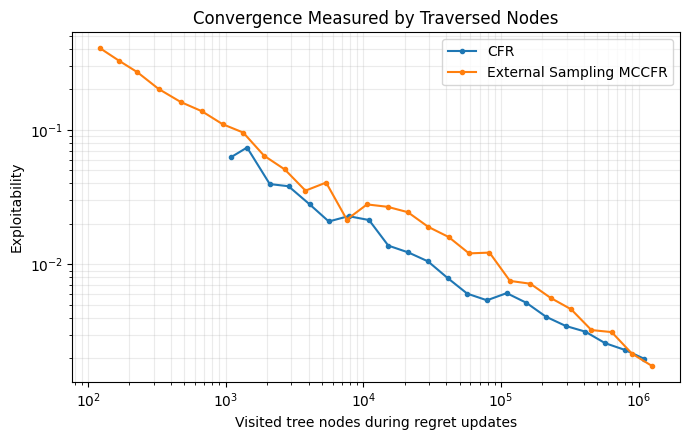

In [7]:
fig, ax = plt.subplots(figsize=(7.0, 4.5))

for algorithm, group in summary.groupby("algorithm"):
    group = group.sort_values("node_visits")
    ax.plot(group["node_visits"], group["exploitability"], marker="o", ms=3, label=algorithm)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Visited tree nodes during regret updates")
ax.set_ylabel("Exploitability")
ax.set_title("Convergence Measured by Traversed Nodes")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "kuhn_mccfr_nodes.png", dpi=200)
plt.show()